# Calibration Comparison

Compare the GP-emulator calibration against the direct FFT-pricer calibration. The notebook reports parameter closeness, fit quality, wall-clock time, and one fitted volatility smile.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PARAMETER_COLUMNS = ["v0", "kappa", "theta", "sigma_v", "rho"]

## Settings

In [12]:
GP_DIR = Path("outputs/gp_calibration")
FFT_DIR = Path("outputs/fft_calibration")
OUTPUT_DIR = Path("outputs/calibration_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GP_SUMMARY_PATH = GP_DIR / "calibration_summary.csv"
FFT_SUMMARY_PATH = FFT_DIR / "calibration_summary.csv"
GP_PREDICTIONS_PATH = GP_DIR / "calibration_predictions.csv"
FFT_PREDICTIONS_PATH = FFT_DIR / "calibration_predictions.csv"

## Load Results

In [13]:
# Load the saved outputs from the two calibration notebooks.
gp_summary = pd.read_csv(GP_SUMMARY_PATH).iloc[0]
fft_summary = pd.read_csv(FFT_SUMMARY_PATH).iloc[0]

gp_predictions = pd.read_csv(GP_PREDICTIONS_PATH)
fft_predictions = pd.read_csv(FFT_PREDICTIONS_PATH)

## 1 Parameter Comparison

In [14]:
# Compare fitted Heston parameters side by side.
parameter_table = pd.DataFrame({
    "parameter": PARAMETER_COLUMNS,
    "gp_calibrated": [gp_summary[column] for column in PARAMETER_COLUMNS],
    "fft_calibrated": [fft_summary[column] for column in PARAMETER_COLUMNS],
})
parameter_table["absolute_difference"] = (
    parameter_table["gp_calibrated"] - parameter_table["fft_calibrated"]
).abs()
parameter_table["relative_difference_pct"] = np.where(
    parameter_table["fft_calibrated"].abs() > 1e-12,
    100.0 * parameter_table["absolute_difference"] / parameter_table["fft_calibrated"].abs(),
    np.nan,
)

parameter_table.to_csv(OUTPUT_DIR / "parameter_comparison.csv", index=False)
parameter_table

,parameter,gp_calibrated,fft_calibrated,absolute_difference,relative_difference_pct
0,v0,0.033038,0.036020,0.002982,8.278068
1,kappa,4.998386,2.650961,2.347425,88.549942
2,theta,0.117082,0.010123,0.106959,1056.593963
3,sigma_v,0.999386,0.999386,0.000000,0.000000
4,rho,-0.949577,-0.949577,0.000000,0.000000


## Parameter Visualization

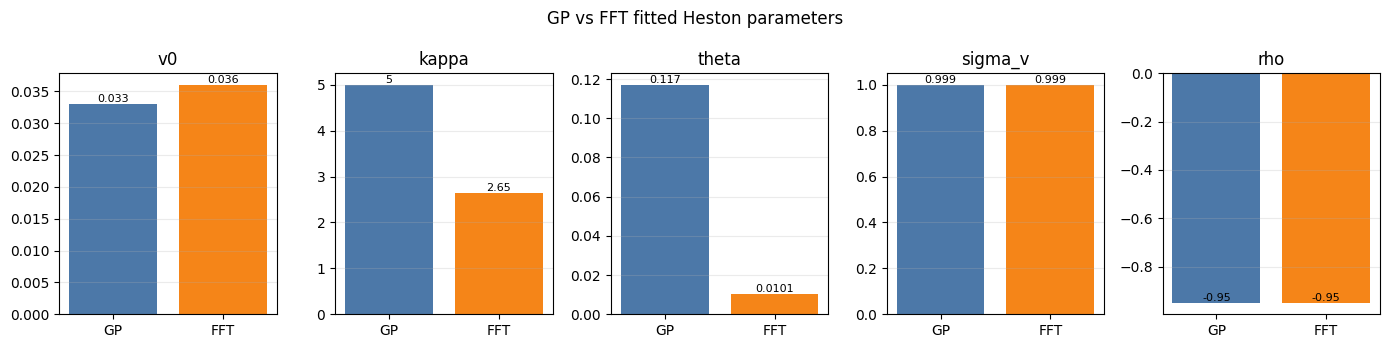

Saved plot to outputs/calibration_comparison/parameter_small_multiples.png


In [15]:
# Use one y-axis per parameter so small-scale parameters stay visible.
fig, axes = plt.subplots(1, len(PARAMETER_COLUMNS), figsize=(14, 3.5))

for ax, row in zip(axes, parameter_table.itertuples(index=False)):
    values = [row.gp_calibrated, row.fft_calibrated]
    ax.bar(["GP", "FFT"], values, color=["#4C78A8", "#F58518"])
    ax.set_title(row.parameter)
    ax.grid(axis="y", alpha=0.25)
    for i, value in enumerate(values):
        ax.text(i, value, f"{value:.3g}", ha="center", va="bottom", fontsize=8)

fig.suptitle("GP vs FFT fitted Heston parameters")
fig.tight_layout()

parameter_plot_path = OUTPUT_DIR / "parameter_small_multiples.png"
fig.savefig(parameter_plot_path, dpi=180)
plt.show()

print(f"Saved plot to {parameter_plot_path}")

## Parameter Discussion

In [16]:
# Summarize where the two calibrations agree or diverge most.
closest = parameter_table.loc[parameter_table["absolute_difference"].idxmin()]
furthest = parameter_table.loc[parameter_table["absolute_difference"].idxmax()]

print(
    f"The closest parameter is {closest.parameter}, with an absolute difference of "
    f"{closest.absolute_difference:.4g}. The largest gap is in {furthest.parameter}, "
    f"where GP={furthest.gp_calibrated:.4g} and FFT={furthest.fft_calibrated:.4g}. "
    "The small-multiple plots are useful here because each parameter has a different natural scale."
)

The closest parameter is sigma_v, with an absolute difference of 0. The largest gap is in kappa, where GP=4.998 and FFT=2.651. The small-multiple plots are useful here because each parameter has a different natural scale.


## 2 Error Comparison

In [17]:
# Compare fit quality using the metrics saved by each calibration notebook.
error_table = pd.DataFrame([
    {
        "method": "GP emulator",
        "total_calibration_error": gp_summary["total_calibration_error"],
        "rmse": gp_summary["rmse"],
        "mae": gp_summary["mae"],
        "contracts": int(gp_summary["contracts"]),
        "success": bool(gp_summary["success"]),
    },
    {
        "method": "FFT pricer",
        "total_calibration_error": fft_summary["total_calibration_error"],
        "rmse": fft_summary["rmse"],
        "mae": fft_summary["mae"],
        "contracts": int(fft_summary["contracts"]),
        "success": bool(fft_summary["success"]),
    },
])

error_table.to_csv(OUTPUT_DIR / "error_comparison.csv", index=False)
error_table

,method,total_calibration_error,rmse,mae,contracts,success
0,GP emulator,21.891259,0.149996,0.091150,973,True
1,FFT pricer,17.649008,0.134680,0.089626,973,True


## Smile Comparison

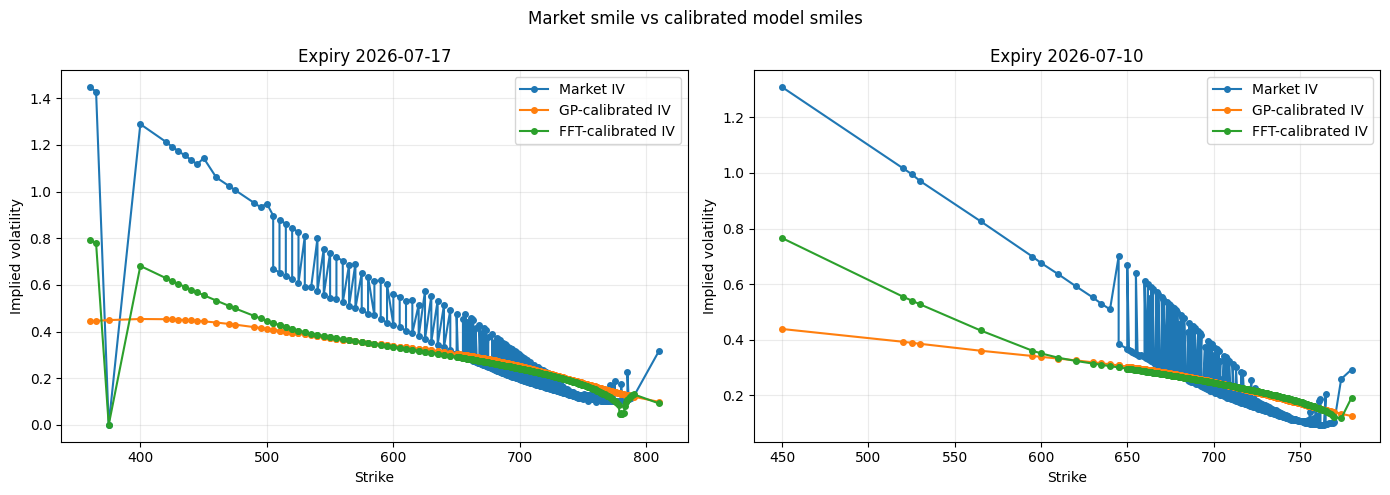

Plotted expiries: 2026-07-17, 2026-07-10
Saved plot to outputs/calibration_comparison/smile_comparison.png


In [18]:
# Merge predictions so the market, GP, and FFT IVs use the same contracts.
plot_data = gp_predictions[[
    "contractSymbol",
    "expiry",
    "strike",
    "market_iv",
    "gp_predicted_iv",
]].merge(
    fft_predictions[["contractSymbol", "fft_predicted_iv"]],
    on="contractSymbol",
    how="inner",
)
plot_data = plot_data.dropna(subset=["market_iv", "gp_predicted_iv", "fft_predicted_iv"])

# Plot the two expiries with the most complete smiles.
selected_expiries = plot_data["expiry"].value_counts().head(2).index.tolist()
fig, axes = plt.subplots(1, len(selected_expiries), figsize=(7 * len(selected_expiries), 5), squeeze=False)

for ax, expiry in zip(axes.ravel(), selected_expiries):
    smile = plot_data.loc[plot_data["expiry"] == expiry].sort_values("strike")
    ax.plot(smile["strike"], smile["market_iv"], "o-", label="Market IV", linewidth=1.5, markersize=4)
    ax.plot(smile["strike"], smile["gp_predicted_iv"], "o-", label="GP-calibrated IV", linewidth=1.5, markersize=4)
    ax.plot(smile["strike"], smile["fft_predicted_iv"], "o-", label="FFT-calibrated IV", linewidth=1.5, markersize=4)
    ax.set_title(f"Expiry {expiry}")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Implied volatility")
    ax.grid(True, alpha=0.25)
    ax.legend()

fig.suptitle("Market smile vs calibrated model smiles")
fig.tight_layout()

smile_plot_path = OUTPUT_DIR / "smile_comparison.png"
fig.savefig(smile_plot_path, dpi=180)
plt.show()

print(f"Plotted expiries: {', '.join(selected_expiries)}")
print(f"Saved plot to {smile_plot_path}")

## Fit Quality Discussion

In [19]:
# Compare aggregate error and the visual smile fit.
gp_rmse = float(gp_summary["rmse"])
fft_rmse = float(fft_summary["rmse"])
better_method = "FFT" if fft_rmse < gp_rmse else "GP"
rmse_gap = abs(gp_rmse - fft_rmse)

print(
    f"The {better_method} calibration has the lower RMSE by {rmse_gap:.4f}. "
    "The smile plots show whether that aggregate difference comes from a broad improvement "
    "across strikes or from a few contracts in the wings."
)

The FFT calibration has the lower RMSE by 0.0153. The smile plots show whether that aggregate difference comes from a broad improvement across strikes or from a few contracts in the wings.


## 3 Runtime Comparison

In [20]:
# Speedup is FFT time divided by GP time. Values above 1 mean the emulator is faster.
gp_time = float(gp_summary["wall_clock_seconds"])
fft_time = float(fft_summary["wall_clock_seconds"])
speedup = fft_time / gp_time

time_table = pd.DataFrame([
    {"method": "GP emulator", "wall_clock_seconds": gp_time, "speedup_vs_gp": 1.0},
    {"method": "FFT pricer", "wall_clock_seconds": fft_time, "speedup_vs_gp": speedup},
])

time_table.to_csv(OUTPUT_DIR / "time_comparison.csv", index=False)
time_table

,method,wall_clock_seconds,speedup_vs_gp
0,GP emulator,3.883935,1.000000
1,FFT pricer,3.495879,0.900087


## Runtime Visualization

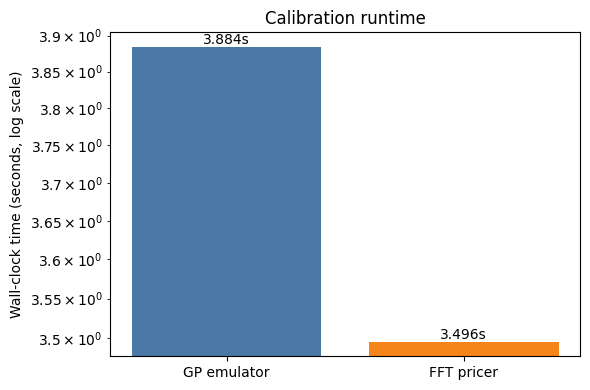

Saved plot to outputs/calibration_comparison/runtime_comparison.png


In [21]:
# Show elapsed calibration time directly; log scale helps when the gap is large.
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(time_table["method"], time_table["wall_clock_seconds"], color=["#4C78A8", "#F58518"])
ax.set_yscale("log")
ax.set_ylabel("Wall-clock time (seconds, log scale)")
ax.set_title("Calibration runtime")
ax.grid(axis="y", alpha=0.25)

for i, row in enumerate(time_table.itertuples(index=False)):
    ax.text(i, row.wall_clock_seconds, f"{row.wall_clock_seconds:.3f}s", ha="center", va="bottom")

fig.tight_layout()
runtime_plot_path = OUTPUT_DIR / "runtime_comparison.png"
fig.savefig(runtime_plot_path, dpi=180)
plt.show()

print(f"Saved plot to {runtime_plot_path}")

## Runtime Discussion

In [22]:
# Interpret elapsed time directly from the saved calibration summaries.
gp_time = float(gp_summary["wall_clock_seconds"])
fft_time = float(fft_summary["wall_clock_seconds"])
ratio = fft_time / gp_time

if ratio > 1:
    message = f"FFT took {ratio:.2f}x as long as GP, so the emulator was faster in this run."
else:
    message = f"FFT took {ratio:.2f}x the GP time, so it was slightly faster in this recorded run."

print(
    message
    + " These times include optimizer behavior, so they reflect the full calibration workflow rather than one model evaluation."
)

FFT took 0.90x the GP time, so it was slightly faster in this recorded run. These times include optimizer behavior, so they reflect the full calibration workflow rather than one model evaluation.


## Efficiency Plot

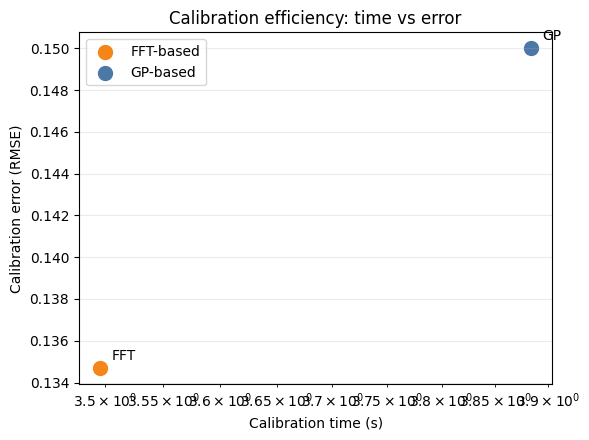

Saved plot to outputs/calibration_comparison/efficiency_time_vs_error.png


In [23]:
# Put speed and fit quality in one view.
gp_error = float(gp_summary["rmse"])
fft_error = float(fft_summary["rmse"])

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter([fft_time], [fft_error], label="FFT-based", s=100, color="#F58518")
ax.scatter([gp_time], [gp_error], label="GP-based", s=100, color="#4C78A8")
ax.set_xscale("log")
ax.set_xlabel("Calibration time (s)")
ax.set_ylabel("Calibration error (RMSE)")
ax.set_title("Calibration efficiency: time vs error")
ax.grid(True, alpha=0.25)
ax.legend()

for label, x, y in [("FFT", fft_time, fft_error), ("GP", gp_time, gp_error)]:
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(8, 6))

fig.tight_layout()
efficiency_plot_path = OUTPUT_DIR / "efficiency_time_vs_error.png"
fig.savefig(efficiency_plot_path, dpi=180)
plt.show()

print(f"Saved plot to {efficiency_plot_path}")

## Efficiency Discussion

In [24]:
# Tie fit quality and runtime together in one conclusion.
gp_error = float(gp_summary["rmse"])
fft_error = float(fft_summary["rmse"])

if gp_error < fft_error and gp_time < fft_time:
    conclusion = "GP dominates here: lower RMSE and faster runtime."
elif fft_error < gp_error and fft_time < gp_time:
    conclusion = "FFT dominates here: lower RMSE and faster runtime."
elif gp_error < fft_error:
    conclusion = "GP is more accurate here, while FFT is faster."
else:
    conclusion = "FFT is more accurate here, while GP is faster."

print(
    conclusion
    + " The time-vs-error scatter is the clearest single view of this tradeoff."
)

FFT dominates here: lower RMSE and faster runtime. The time-vs-error scatter is the clearest single view of this tradeoff.
